In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/features_v2.csv")

df.head()

,raceId,driverId,constructorId,circuitId,year,date,grid,positionOrder,points,avgLapTime_s,pitStopCount,driver_form_avg,constructor_form_avg,driver_experience,constructor_points_roll5,driver_circuit_avg_finish,circuitType_street,era_ground_effect,era_hybrid,era_v8
0,224,50,29,1,1996,1996-03-10,12,17,0.0,100.697467,0.0,19.8,0.8,2,0.8,14.242991,True,False,False,False
1,224,30,6,1,1996,1996-03-10,4,13,0.0,99.427094,0.0,4.0,0.6,5,0.6,6.879870,True,False,False,False
2,224,22,17,1,1996,1996-03-10,8,15,0.0,98.117655,0.0,14.0,0.6,3,0.6,10.334356,True,False,False,False
3,224,14,1,1,1996,1996-03-10,13,16,0.0,99.797708,0.0,7.8,1.8,2,1.8,9.485830,True,False,False,False
4,224,55,22,1,1996,1996-03-10,6,18,0.0,97.365889,0.0,8.8,3.0,7,3.0,11.252475,True,False,False,False


In [2]:
df["podium"] = (df["positionOrder"] <= 3).astype(int)

df["podium"].value_counts(normalize=True)

podium
0    0.850752
1    0.149248
Name: proportion, dtype: float64

In [3]:
finish_features = joblib.load("../models/finishing_position_features.joblib")

X = df[finish_features]
y = df["podium"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=300, random_state=42)

In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1856
           1       0.68      0.62      0.65       326

    accuracy                           0.90      2182
   macro avg       0.81      0.78      0.79      2182
weighted avg       0.90      0.90      0.90      2182



In [8]:
roc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc)

ROC AUC: 0.9254589657816797


[[1760   96]
 [ 124  202]]


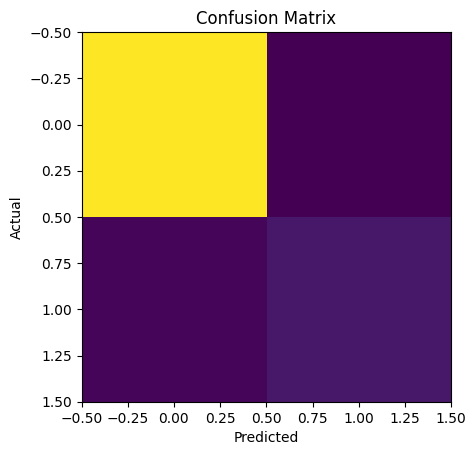

In [9]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
importances = pd.Series(
    model.feature_importances_,
    index=finish_features
).sort_values(ascending=False)

importances.head(15)

grid                         0.294959
driver_form_avg              0.166033
constructor_form_avg         0.138617
constructor_points_roll5     0.126476
driver_circuit_avg_finish    0.074909
driver_experience            0.055977
year                         0.051876
circuitId                    0.047896
pitStopCount                 0.021536
circuitType_street           0.007925
era_v8                       0.005965
era_hybrid                   0.005122
era_ground_effect            0.002708
dtype: float64

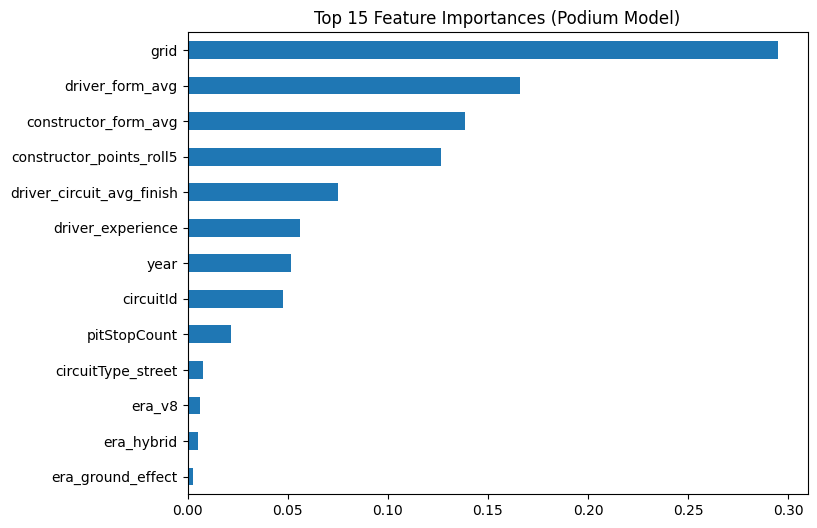

In [11]:
plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Podium Model)")
plt.show()

In [12]:
sample = X_test.iloc[[0]]
prob = model.predict_proba(sample)[0][1]

print("Sample podium probability:", prob)

Sample podium probability: 0.009112121227549869


In [13]:
joblib.dump(model, "../models/podium_model.joblib")
joblib.dump(finish_features, "../models/podium_features.joblib")

['../models/podium_features.joblib']